# Investigation of the Large Angle Pendulum Motion and Comparing it to the Small Angle Approximation 

## By Samuel Khan

# Introduction

A pendulum is a classical system that usually consists of a spherical uniform mass m hanging from a string with length L from a point. When you release the mass with an angle it will then swing back and forth with periodic motion [1]. An assumption that was made for these calculations is that the string is taut meaning the string is constantly fully stretched out [1]. Galileo was one of the first to examine this feature and tried to make the clock but failed, in which Christian Huygens then managed to make it [2]. We can use Newton's second law of motion and angular motion: 

\$ F = ma $ (1) 

and 

$\ τ = Iα $ (2) [3] 

to derive the motion of a pendulum which is:

$\ -mgsin(θ)L =  mL^2(d^2θ/dt^2) $ (3) 

which can then be rearranged to:

$\ (d^2θ/dt^2) + (g/L)(sin(θ)) = 0 $ (4)

where \$ d^2θ/dt^2 \$ is the angular angular acceleration, \$ g = 9.81m/s^2 $ and θ is the angle of the pendulum [1]

We can take this a step further by using the small angle approximation sinθ \$ \\approx θ $ to get:

\$ θ(t) = θ_0 cos(𝜔t) $ (5)

\$ T = 2π \sqrt{L/g} $    (6)

However, equation 5 only works for small angle approximations since pendulums at larger angles show non linear properties which would depend on other factors such as amplitude [4].

In this project I will investigate the different properties of the pendulum by using differential equations and compare different initial conditions such as, varying the initial angle, adding and varying the initial velocity, comparing the nonlinear pendulum and the small angle approximation version pendulum, and lastly, how the period varies with angular velocity. I will do this by importing solve_ivp from scipy.integrate and solving the equations using this function as well as plotting graphs to make visual comparisons [5].

# Method

In this project I will use solve_ivp from the SciPy library to solve the ordinary differential equations (ODEs) for the non linear and small angle approximation pendulum [5]. The aim is to compare how the motion of the pendulum is changed when changing the variables of it. The solve_ivp method automatically defaults to the RK45 method if not changed, which I used because it is more adaptive because it has an in built error control whenever the values would drastically change compared to the other methods that I used in the labs portfolio such as the Euler method and RK2 method which tend to be slightly wrong and have more errors. In solve_ivp the solver allows varying the step size to reduce error by changing the tolerance in rtol and atol, in which it can either increase or decrease the step size [5]. I kept the atol and rtol equal to 1e-9 to keep the project as consistent as possible and since it is small, it works better at the turning points of the pendulum. I can also vary the integral interval inside the solve_ivp by just doing t_span = (lower bound, upper bound) in brackets inside the function. I set the solver to integrate the ODE over a time interval from 0 seconds to 20 seconds, to not only get enough to potentially see any errors but not too long that it would cause the code to take a long time to run. 

With this information we can use the formula of the equation of a pendulum (4):

$\ (d^2θ/dt^2) + (g/L)(sin(θ)) = 0 $

We can get that the angular velocity 𝜔 is:

\$ 𝜔 = dθ/dt $ (7)

and that,

\$ d𝜔/dt = -(g/L)sin(θ) $ (8)

and now the 2nd order differential can be written in first order ODEs which is good since solve_ivp works in first order ODEs [5]. The output that the solver gives, sol.y[0] is the angular displacement, sol.y[1] is the angular velocity and sol.t is the time values. Although I wrote the initial angles in degrees for easier readability and understanding, for the code I had to change it to radians using deg2rad(x) from numpy, then I switched it back after the calculations using rad2deg(x) [6]. This is because python's trigonometric functions works in radians and does not work in degrees. 

When making the code, I made the initial decision to let the length L = 1 and g = 9.81 for all the code as it would keep every example simple and consistent. when making the t_eval for solve_ivp i used the code:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

g = 9.81
L = 1.0

t_total = 20
t_eval = np.linspace(0, t_total, 20000)

This would make it so the solver would would make 20,000 evenly spaced points between the 0 to 20 second interval. If i didn't do this then the solver would default to none, and the data points would wildly vary and it would be different every time you run the code [5].

The pendulum system I made is shown below, using the first order differentials so it works for solve_ivp:  

In [2]:
def pendulum(t,y):
    theta, omega = y
    dtheta = omega
    domega = -(g/L) *np.sin(theta)
    return [dtheta, domega]

Which is then simplified to:

In [3]:
def pendulum(t,y):
    theta, omega = y
    return [omega, -(g/L)*np.sin(theta)]

## Test 1

In the first test I wanted to compare how the initial angle of the pendulum would affect the period of motion, and for that I made a list called initial_angles of 10,30,60 and 90 and then made a for loop for y0, where y0 = ["angle","omega"] is the initial vector, to then use the solver to solve for these different initial angles and plot each motion on an angle against time graph [5]. For y0 I set omega/the second term inside the sqaure brackets to 0 as it is meant to be dropped from rest.

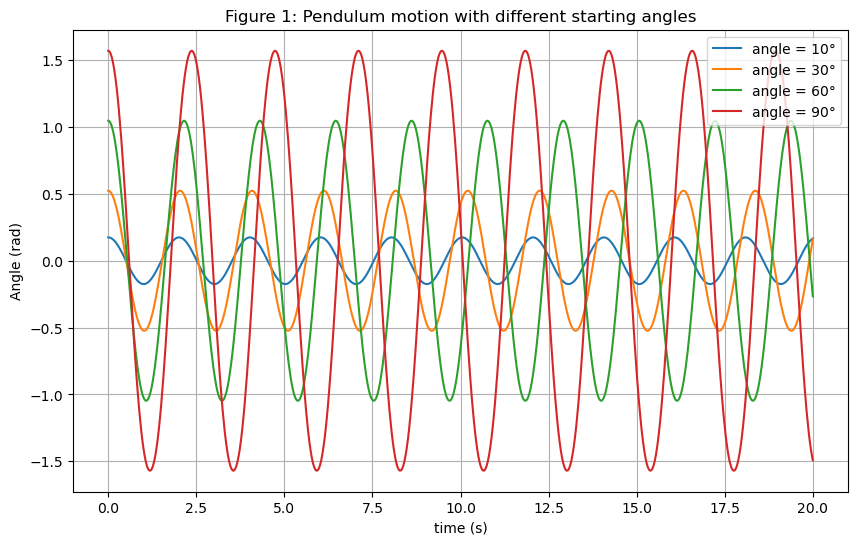

In [4]:
#Testing different initial angles

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

g = 9.81
L = 1.0

def pendulum(t,y):
    theta, omega = y
    dtheta = omega
    domega = -(g/L) *np.sin(theta)
    return [dtheta, domega]

t_total = 20.0
t_eval = np.linspace(0, t_total, 20000)

initial_angles = [10,30,60,90] # in degrees
initial_angles = [np.deg2rad(a) for a in initial_angles] # in radians

plt.figure(figsize=(10,6))

for theta0 in initial_angles:
    y0 = [theta0,0.0]
    sol1 = solve_ivp(pendulum, (0,t_total), y0,rtol = 1e-9, atol = 1e-9)
    plt.plot(sol1.t,sol1.y[0], label = "angle = " + str(round((np.rad2deg(theta0)))) + "°")
    
plt.xlabel("time (s)")
plt.ylabel("Angle (rad)")
plt.title("Figure 1: Pendulum motion with different starting angles")
plt.legend(loc = "upper right")
plt.grid()

## Test 2

For the second test I wanted to varying the initial velocity from the same fixed angle of 45 degrees to see how the initial velocity affects it. For this it is almost the same, but the list I made the loop for is for the angular velocity instead, and for y0 = ["angle","omega"], the first term is just 45 degrees, and the second term takes each value from the velocity list to then use solve_ivp to integrate and plot each initial velocity motion on another angle vs time graph.

Text(0.5, 1.0, 'Figure 2: Comparing different initial velocites')

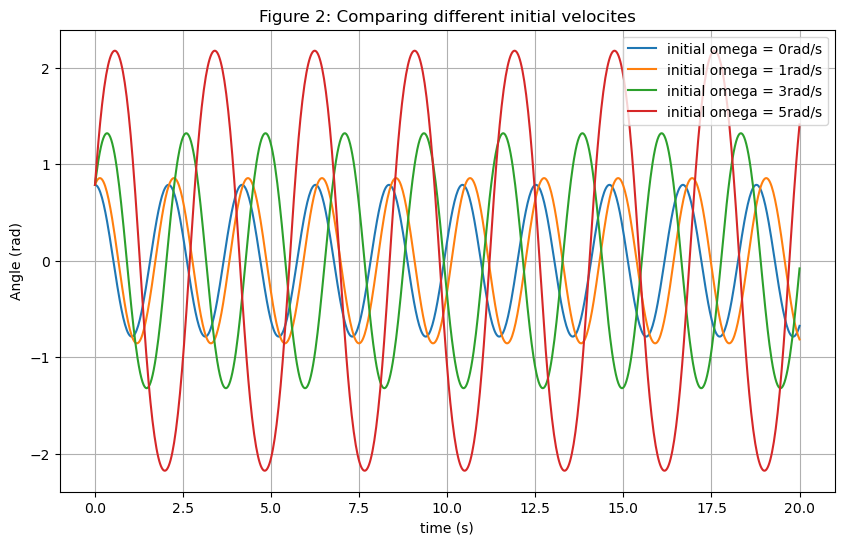

In [5]:
#testing different initial velocities

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

g = 9.81
L = 1.0

def pendulum(t,y):
    theta, omega = y
    dtheta = omega
    domega = -(g/L) *np.sin(theta)
    return [dtheta, domega]

t_total = 20.0
t_eval = np.linspace(0, t_total, 20000)

initial_velocities = [0,1,3,5]
theta0 = np.deg2rad(45)

plt.figure(figsize=(10,6))

for omega0 in initial_velocities:
    y0 = [theta0, omega0]
    sol2 = solve_ivp(pendulum, (0,t_total),y0,rtol = 1e-9, atol = 1e-9)
    plt.plot(sol2.t,sol2.y[0],label = "initial omega = " + str(omega0)+"rad/s")
plt.legend(loc = "upper right")
plt.xlabel("time (s)")
plt.ylabel("Angle (rad)")
plt.grid()
plt.title("Figure 2: Comparing different initial velocites")

## Test 3

For the third part of this project, I wanted to see how good the small angle approximation is compared to the non linear pendulum and I also wanted to check the energy conservation to see the accuracy of the solve_ivp function. 

I used the same solve_ivp technique to solve for the non linear where kept the angle at 60 degrees and the initial velocity at 0. For the small angle approximation I used equation (5) where theta0 would also be 60 degrees and plotted both of these curves of the same graph to compare how different they are. 

To check the accuracy, I calculated the total mechanical energy at each point using the equations below while also make the mass = 1:

\$ E = K + U $ (9)

which we can then turn into:

\$ E = (1/2) 𝜔^2 + g(1-cosθ) $ (10)

Where the the first term is the kinetic energy and the second term is the gravitational potential energy. We should expect the energy to be constant when comparing it to different times since the pendulum is conservative. I then calculated what the maximum energy change and plotted an energy drift vs time graph to see if and what errors the solve_ivp is getting.

Maximum energy change: 2.5853543217380093e-07


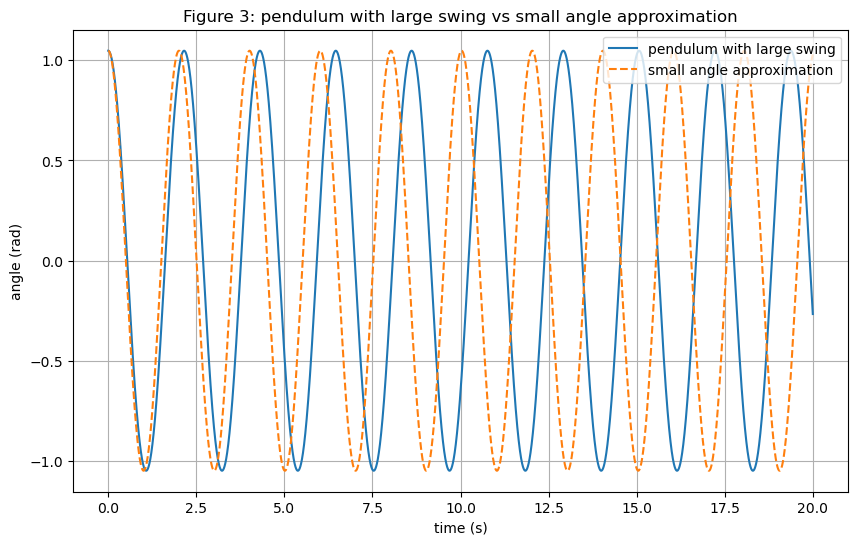

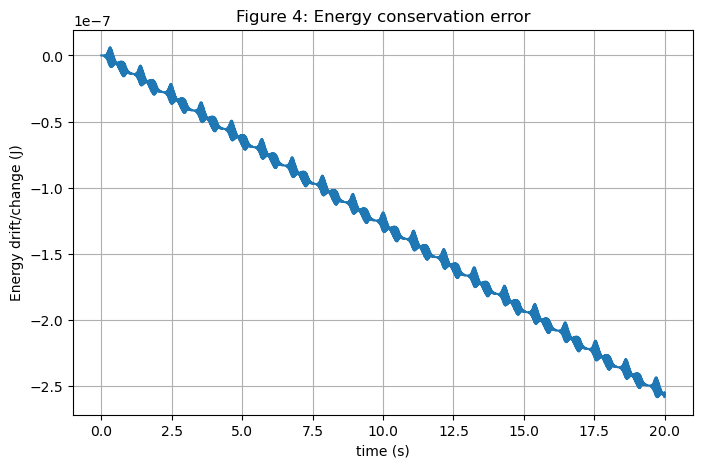

In [6]:
#testing small angle approximation and energy conservation error

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

g = 9.81
L = 1.0

def pendulum(t,y):
    theta, omega = y
    return [omega, -(g/L)*np.sin(theta)]

t_total = 20
t_eval = np.linspace(0, t_total, 20000)

theta0 = np.deg2rad(60)
omega0 = 0
y0 = [theta0,omega0]

sol3 = solve_ivp(pendulum, (0,t_total),y0,t_eval = t_eval,rtol = 1e-9, atol = 1e-9) #pendulum with large swing
theta = sol3.y[0]
omega = sol3.y[1]

w = np.sqrt(g/L)
small_angle_app = theta0 * np.cos(np.sqrt(g/L) * t_eval) #pendulum with small angle approximation

E = 0.5 * omega**2 + g * (1 - np.cos(theta)) 

plt.figure(figsize=(10,6))
plt.plot(t_eval, sol3.y[0], label = "pendulum with large swing")
plt.plot(t_eval, small_angle_app,"--", label = "small angle approximation")
plt.legend(loc = "upper right")
plt.grid()
plt.xlabel("time (s)")
plt.ylabel("angle (rad)")
plt.title("Figure 3: pendulum with large swing vs small angle approximation")

plt.figure(figsize=(8,5))
plt.plot(sol3.t, E - E[0])
plt.xlabel("time (s)")
plt.ylabel("Energy drift/change (J)")
plt.title("Figure 4: Energy conservation error")
plt.grid()

print("Maximum energy change:", np.max(np.abs(E - E[0])))

## Test 4

Next I wanted to compare how the angular velocity 𝜔 varies with it's angle θ. So I created another list of initial angles ranging from small angles like 30 degrees to large angles such as 210. The pendulum is also released from rest so y0 = ["initial angles", 0]. I used the fact that sol.y[0] gives me the angle and sol.y[1] would give me the angular velocity from the solve_ivp function. I also had to get θ into the interval -π to π as it would keep all the angles within the same region and stop some angles from going out of range. I did this by using the comment code below:

code: (theta + np.pi) % (2*np.pi) - np.pi

Then I plotted an 𝜔 vs θ graph to compare how the motion of the pendulum changes for different initial angles and allows us to visualise the behaviour of the system much more clearly.

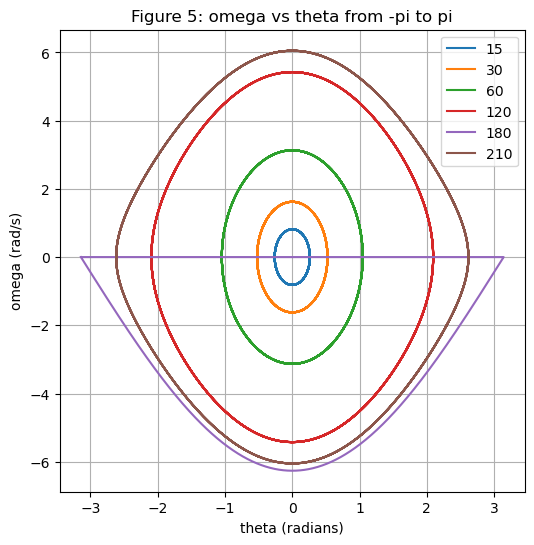

In [7]:
#plotting omega vs theta

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

g = 9.81
L = 1.0

def pendulum(t,y):
    theta, omega = y
    return [omega, -(g/L)*np.sin(theta)]

t_total = 20
t_eval = np.linspace(0, t_total, 20000)

initial_angle = np.deg2rad([15,30,60,120,180,210])

plt.figure(figsize=(6,6))

for ia in initial_angle:
    y0 = [ia, 0]
    sol4 = solve_ivp(pendulum, (0,t_total),y0,t_eval = t_eval,rtol = 1e-9, atol = 1e-9)
    theta = sol4.y[0]
    omega = sol4.y[1]
    #plt.plot(theta,omega, label = round(np.rad2deg(ia))) #without the wrapping
    plt.plot((theta + np.pi) % (2*np.pi) - np.pi,omega, label = round(np.rad2deg(ia))) # with the wrapping
plt.xlabel("theta (radians)")
plt.ylabel("omega (rad/s)")
plt.title("Figure 5: omega vs theta from -pi to pi")
plt.legend()
plt.grid()

## Test 5

Lastly I wanted to compare how the period of the pendulum changes as the initial angle increases and compare how the non linear pendulum would look compared to the small angle approximation. First I made linspace from numpy to vary my angles from 1 degree to 90 degrees in 20 evenly spaces as shown by the code below:

In [8]:
PvsI_angles = np.deg2rad(np.linspace(1,90,20))

I wanted the pendulum to also be dropped and not have initial velocity so I made y0 = ["angles in the linspace from 1 to 90", 0]. 

To get the period from the of the solution I had to find where the pendulum passes through 0, and I had to do this twice to get one full swing. Then the period was calculated by subtracting the two times the pendulum crossed zero and if there there weren't periods to be calculated it would record NaN.

For the small angle approximation, I used equation (6) and since the length of the pendulum string is constant, the period of the pendulum is also constant and wouldn't vary therefore I plotted a straight line using equation (6)

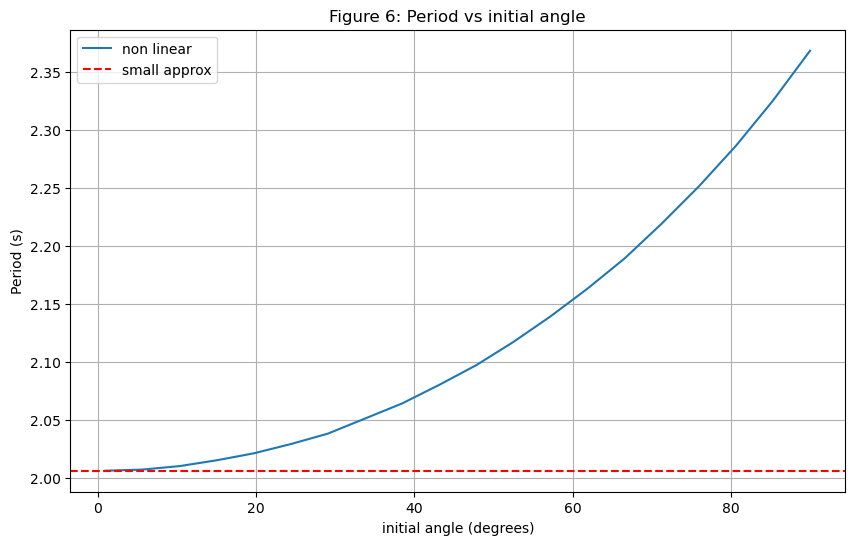

In [9]:
# period vs initial angle for non linear pendulum and small approximation

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

g = 9.81
L = 1.0

def pendulum(t,y):
    theta, omega = y
    return [omega, -(g/L)*np.sin(theta)]

t_total = 20
t_eval = np.linspace(0, t_total, 20000)

PvsI_angles = np.deg2rad(np.linspace(1,90,20))

periods = []

for PIA in PvsI_angles:
    y0 = [PIA, 0]
    sol5 = solve_ivp(pendulum, (0,t_total),y0,t_eval = t_eval,rtol = 1e-9, atol = 1e-9)
    thetaPvsI = sol5.y[0]
    oscillationcross = []
    for i in range(len(thetaPvsI) - 1):
        if thetaPvsI[i] < 0 and thetaPvsI[i+1] >= 0:
            oscillationcross.append(sol5.t[i])
    if len(oscillationcross) >= 2:
        accept = oscillationcross[1] - oscillationcross[0]
        periods.append(accept)
    else:
        periods.append(np.nan)

small_angle_T = 2*np.pi * np.sqrt(L/g)

plt.figure(figsize=(10,6))
plt.plot(np.rad2deg(PvsI_angles), periods, label = "non linear")
plt.axhline(small_angle_T, color = "r", linestyle = '--', label = "small approx")
plt.legend()
plt.xlabel("initial angle (degrees)")
plt.ylabel("Period (s)")
plt.title("Figure 6: Period vs initial angle")
plt.grid()

# Results and Discussion 

### Test 1
Figure 1 shows that as the initial angle increases, the oscillation period also increases. The curves show that the pendulum slows down noticeably near the turning points for larger initial angles meaning that each swing takes longer to complete. This is due to the fact that the restoring torque: 

\$ τ = -mgLsinθ $, (11)

becomes less effective effective at larger angles. Since sinθ grows more slowly at larger θ, the restoring force no longer acts proportionally to displacement. This causes the pendulum motion to act in a non linear motion and is more apparent at larger angles. This comparison becomes easier to see if you compare the 10 degree curve to the 90 degree curve where you can visually see that the 90 degree curve looks more shifted to the right because it has a longer turning point time. Where as 10 degrees and 30 degrees look pretty similar.

### Test 2

Figure 2 shows how varying the the initial angular velocity when released from the same angle of 45 degrees affects the pendulums motion. As the velocity increases, the pendulum reaches larger angular displacements. This is because as the initial velocity increases, the kinetic energy would then increase, which would allow the pendulum to reach higher heights before going back which aligns with the conservation of energy and mechanical energy (10). 

The curve also shows that pendulums with higher initial velocities also have longer periods because the larger swings would lead to non linear effects that is the same as the effects shown in test 1. As a results the pendulum slows down more at the turning point with higher velocities causing the oscillations to take more time. This is shown when you compare the 1 rad/s curve to the 5 rad/s curve where it almost immediately goes out of sync and the 0 rad/s and 1 rad/s are somewhat close to being similar.

### Test 3

Figure 3 compares the numerical solution of the pendulum released from a large initial angle of 60 degrees with the small angle approximation model. Initially the two curves follow a similar behaviour, but then they quickly diverge as time progresses. This happens because the small-angle approximation assumes \$ sinθ \\approx θ $, which is only valid for very small displacement. At large angles sinθ grows much slowly than θ, meaning that the small angle approximation may not take into account the longer times it would take during the turning the points of the swings. As a result, the approximation shows a shorter period and smaller oscillations compared to the non linear pendulum motion. 

Figure 4 shows how the total mechanical energy changes during the test. Usually for a pendulum the energy should remain constant. However, figure 4 shows the numerical error accumulating over the test causing an energy change to move starting from 0e-7 increasing to a maximum of 2.5853e-7. Although the error is very small and well conserved, the non linearity of the pendulum motion causes the system to have more errors when using the solve_ivp function which makes some numerical errors. So the printed maximum energy change of 2.5853e-7 shows that it is still very accurate but as time would go on this error would become more prominent.

### Test 4

Figure 5 shows how I plotted angular velocity against angle for a range of angles to make a phase space diagram to represent the behaviour of the system. Most of the curves form a closed loop representing the continuous movement of the pendulum and continuous change between kinetic and potential energy during the motion. For smaller angles, like 15,30 and 60 degrees, the loops look almost perfectly elliptical which shows the characteristics of simple harmonic motion and that the motion is linear.

However, as the initial angle increases, the the loops change slowly change shape and become more distorted as shown with angles 120 and 210. This is due to the non linear behaviour of the pendulums at larger angles causing the pendulum to spend more time at the turning points, showing flattening at the 4 ends of the oval.

The wrapping applied to the plot (-π =< θ =< +π) makes sure that the pendulum motion remain continuous and meaningful and stop creating any weird gaps as well as keeping all the data on the right part of the axis. 

An angle that shows different behaviour on the graph is 180 degrees. It goes from directly above the starting point or in other words above the pivot, as since it is an unstable equilibrium it could go in either direction. As it goes back to the top during the full rotation, the angle is perceived by the code as going from -π to +π or +π to -π in the data. So then the code plots a straight line across the plot making it seem like it teleport across the graph even though we know that is not how the pendulum acts. So the solve_ivp and plotting function has problems solving with multiples of 180.

Overall this plot shows how the small angles and larger angles show different behaviours and other different characteristics even if does not work properly with certain angles such as any multiples of 180 degrees.

### Test 5

Figure 6 shows how the period of the pendulum changes as the initial angle increases for a non linear pendulum model as well what the small angle approximation looks like using equation (6). The non linear model shows that the period increases steadily as the angle becomes larger. This behaviour contrasts the small angle approximation because the approximation is just a straight line as shown by the dashed line on the graph. For small angles that are about less than 10 degrees, the non linear model is very similar to the approximation. However as the angle increases it goes out of this range and clearly becomes non linear. This is because the higher angles take more time at the turning points therefore the periods become longer. The plot shows the difference since at about 30 degrees, the curve starts to rise much faster showing that the approximation breaks down before then.

# Conclusion 

This project studied the motion of a pendulum using integration with solve_ivp from the SciPy library. The results show that at larger initial angles and higher initial velocities, both the amplitude and period of the oscillation increases. This happens because the pendulum becomes more non linear at larger angles, so the time spent at the turning points are longer because the restoring force becomes less effective. 

Comparing the non linear motion and small angle approximation, it showed that as we expected, the approximation only works for small angles and becomes less accurate for larger swings because it doesn't take into account the other factors such as longer turning point times because of the restoring force.

The phase space plots show how the motion changes with amplitude, showing nicer closed loops for the smaller angles and more distorted angles shapes at larger angles.

Overall, this project demonstrates how good the small angle approximation is compared to the non linear model and how we need to use the non linear model if we want to explore more realistic effects and I was able to do this thanks to solve_ivp function doing the integration for me using first order differentials.

# References

[1] https://www.acs.psu.edu/drussell/Demos/Pendulum/Pendula.html

[2] https://www.tau.ac.il/education/muse/museum/galileo/pendulum.html#:~:text=Galileo%20was%20the%20first%20to,the%20beginning%20of%20the%20period.

[3] https://openstax.org/books/university-physics-volume-1/pages/10-7-newtons-second-law-for-rotation

[4] https://www.maths.tcd.ie/~oconbhup/labs/Non-Linear%20Pendulum/Pendreport.pdf

[5] https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html

[6] https://www.geeksforgeeks.org/python/numpy-radians-deg2rad-python/

In [10]:
import nbformat
def word_count(notebook):
    """Prints the word count in Markdown cells of the file named notebook."""
    with open(notebook, 'r', encoding='utf-8') as f:
        nb = nbformat.read(f, as_version=4)
    word_count = 0
    total_word_count = 0
    for cell in nb['cells']:
        if cell['cell_type'] == "markdown":
            lines = cell['source'].split('\n')
            for line in lines:
                if len(line) > 0 and line[0] == '#':
                    print(word_count)
                    total_word_count += word_count
                    word_count = 0
                    print(line.strip(), end=" ==> ")
                else:
                    word_count += len(line.lstrip().split(' '))
    print(word_count)
    print("Total ==> ", total_word_count)
word_count("FinalCodingProject.ipynb")

0
# Investigation of the Large Angle Pendulum Motion and Comparing it to the Small Angle Approximation ==> 1
## By Samuel Khan ==> 0
# Introduction ==> 336
# Method ==> 519
## Test 1 ==> 96
## Test 2 ==> 90
## Test 3 ==> 217
## Test 4 ==> 155
## Test 5 ==> 185
# Results and Discussion ==> 0
### Test 1 ==> 154
### Test 2 ==> 167
### Test 3 ==> 224
### Test 4 ==> 337
### Test 5 ==> 152
# Conclusion ==> 202
# References ==> 18
Total ==>  2835
